In [33]:
import icechunk
import matplotlib.pyplot as plt
import zarr

from srm import catalog
from srm.downscaling_utils import interpolate_fine_to_coarse_grid, rechunk
from srm.qaqc import (
    disagg_test_calculate_metrics,
)
from srm.utils import open_icechunk
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
from dask.distributed import Client

## Get data

In [3]:
path_output = (
    "s3://carbonplan-srm/output/production/CESM2-WACCM-ERA5-global.icechunk"
)
var = "pr"
scenario = "historical"
ens = "r3i1p1f1"
branch = "v0.11.0"

In [4]:
client = Client()

2026-07-23 20:11:28,035 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 1817d7f190714b6fa715b7a266a99821 initialized by task ('rechunk-merge-rechunk-transfer-537cab83709f8e25ee9b319028120c53', 2, 0, 0, 3, 5, 0) executed on worker tcp://127.0.0.1:40863
2026-07-23 20:11:29,161 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle a6a9273b36750c5eecf083d87b2537fb initialized by task ('rechunk-merge-rechunk-transfer-537cab83709f8e25ee9b319028120c53', 0, 0, 0, 0, 9, 0) executed on worker tcp://127.0.0.1:37625
2026-07-23 20:11:30,084 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 1817d7f190714b6fa715b7a266a99821 deactivated due to stimulus 'task-finished-1784837490.0817635'
2026-07-23 20:11:30,379 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle a6a9273b36750c5eecf083d87b2537fb deactivated due to stimulus 'task-finished-1784837490.3769243'
2026-07-23 20:11:34,116 - distributed.scheduler - ERROR - Task 'finalize-hlgfinalizecompute-bf8508e6e3d04344abe7

In [5]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: https://cluster-dsnab.dask.host/jupyter/proxy/8787/status,
Dashboard: https://cluster-dsnab.dask.host/jupyter/proxy/8787/status,Workers: 8
Total threads: 64,Total memory: 244.47 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46389,Workers: 0
Dashboard: https://cluster-dsnab.dask.host/jupyter/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33965,Total threads: 8
Dashboard: https://cluster-dsnab.dask.host/jupyter/proxy/45197/status,Memory: 30.56 GiB
Nanny: tcp://127.0.0.1:35455,


In [6]:
storage = icechunk.s3_storage(
    bucket="carbonplan-srm",
    prefix="output/production/CESM2-WACCM-ERA5-global.icechunk/",
    region="us-west-2")
repo = icechunk.Repository.open(storage)
print(repo.list_branches())
session = repo.readonly_session(branch=branch)
root = zarr.open_group(session.store, mode="r")
# print(root.tree())

{'main', 'v0.7.0', 'v0.11.0', 'v0.10.0', 'v0.8.0', 'v0.11.1'}


In [7]:
lat_slice = slice(-35, -22)
lon_slice = slice(16, 33)

In [8]:
coarse_debiased = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/" + scenario + "/" + var + "/" + ens,
)[var]
debiased_downscaled = open_icechunk(
    path=path_output,
    branch=branch,
    group=scenario + "/" + var + "/" + ens,
)[var]

In [9]:
obs_fine = catalog.get("ERA5").to_xarray()[var]
obs_fine = obs_fine.sel(time=slice('1978', '2014'))

In [10]:
obs_coarse = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=obs_fine, da_coarse_grid=coarse_debiased
).compute()

In [13]:
coarse_debiased = rechunk(coarse_debiased, pattern="full_space").persist()

# Compare different steps of the process

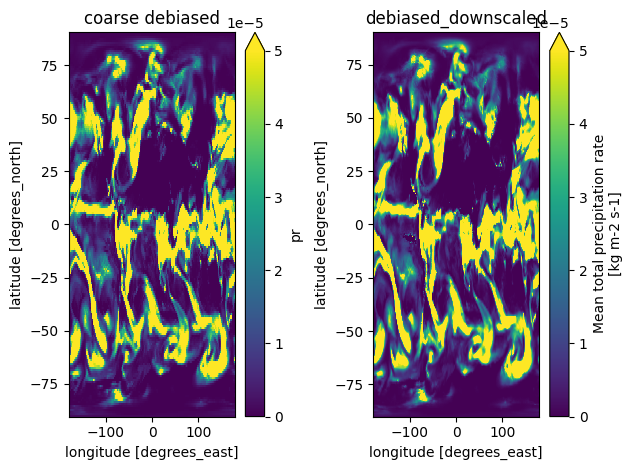

In [15]:
vmax=5e-5
plt.subplot(1, 2, 1)
coarse_debiased.isel(time=0).plot(vmax=vmax)
plt.gca().set_title('coarse debiased')

plt.subplot(1, 2, 2)
debiased_downscaled.isel(time=0).plot(vmax=vmax)
plt.gca().set_title('debiased_downscaled')
plt.tight_layout()

# Do evaluation

In [ ]:
# DOY downscaled
debiased_downscaled_doy = debiased_downscaled.groupby("time.dayofyear").mean().compute()

In [18]:
# DOY coarse
coarse_debiased_doy = coarse_debiased.groupby("time.dayofyear").mean().compute()

In [19]:
obs_fine_doy = obs_fine.groupby("time.dayofyear").mean().compute()
obs_coarse_doy = obs_coarse.groupby("time.dayofyear").mean().compute()

In [38]:
mean_obs = obs_fine.mean(dim='time').compute()
mean_downscaled = debiased_downscaled.mean(dim='time').compute()

In [39]:
mean_obs_coarse = obs_coarse.mean(dim='time').compute()
mean_coarse_debiased = coarse_debiased.mean(dim='time').compute()

In [40]:
pbias_fine = ((mean_downscaled-mean_obs)/mean_obs*100).compute()
mae_fine = ((mean_downscaled-mean_obs)).compute()

In [41]:
pbias_coarse = ((mean_coarse_debiased-mean_obs_coarse)/mean_obs_coarse*100).compute()
mae_coarse = ((mean_coarse_debiased-mean_obs_coarse)).compute()

# Evaluate bias in coarse

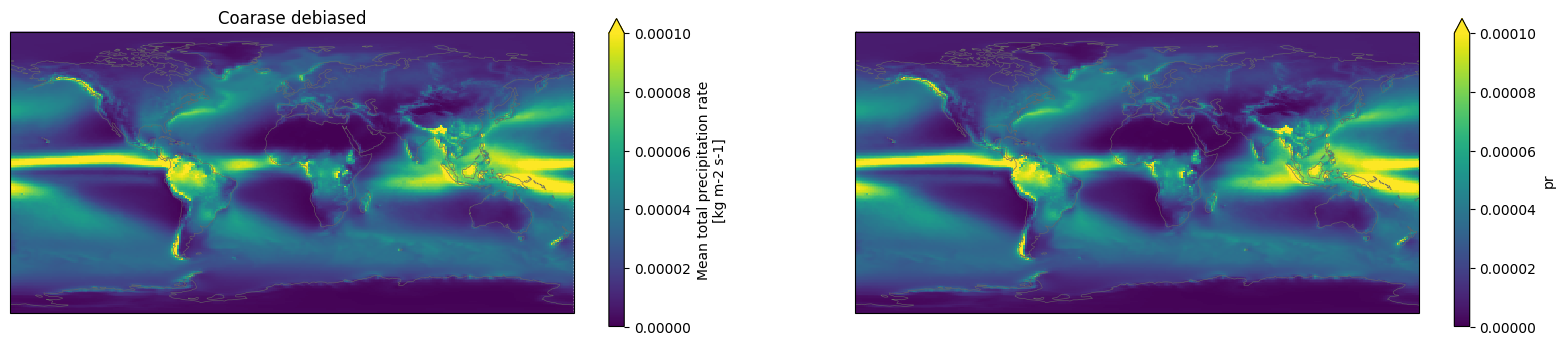

In [64]:
fig, axarr = plt.subplots(1,2, figsize=(20,4), subplot_kw={"projection": ccrs.PlateCarree()})

mean_obs_coarse.plot(ax=axarr[0], cmap='viridis', vmin=0, vmax=1e-4, transform=ccrs.PlateCarree())
axarr[0].set_title('Coarse obs')
mean_coarse_debiased.plot(ax=axarr[1], cmap='viridis', vmin=0, vmax=1e-4, transform=ccrs.PlateCarree())
axarr[0].set_title('Coarase debiased')
for ax in axarr:
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(14,8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
mean_obs_coarse.plot(ax=ax, cmap='viridis', robust=True, transform=ccrs.PlateCarree(), cbar_kwargs={"label": "Bias [%]", "shrink": 0.8})

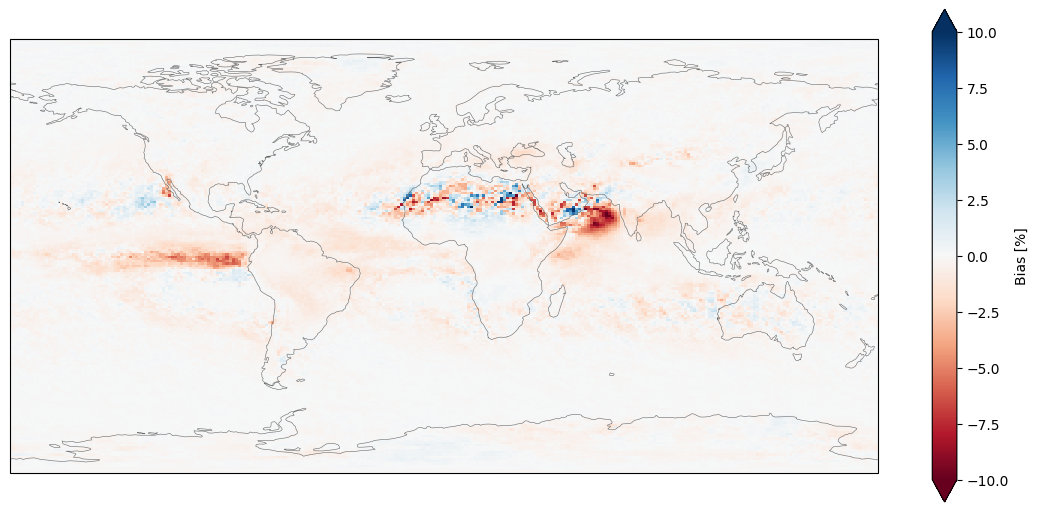

In [44]:
fig, ax = plt.subplots(1,1, figsize=(14,8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
pbias_coarse.plot(ax=ax, vmin=-10, vmax=10, cmap='RdBu', transform=ccrs.PlateCarree(), cbar_kwargs={"label": "Bias [%]", "shrink": 0.8})

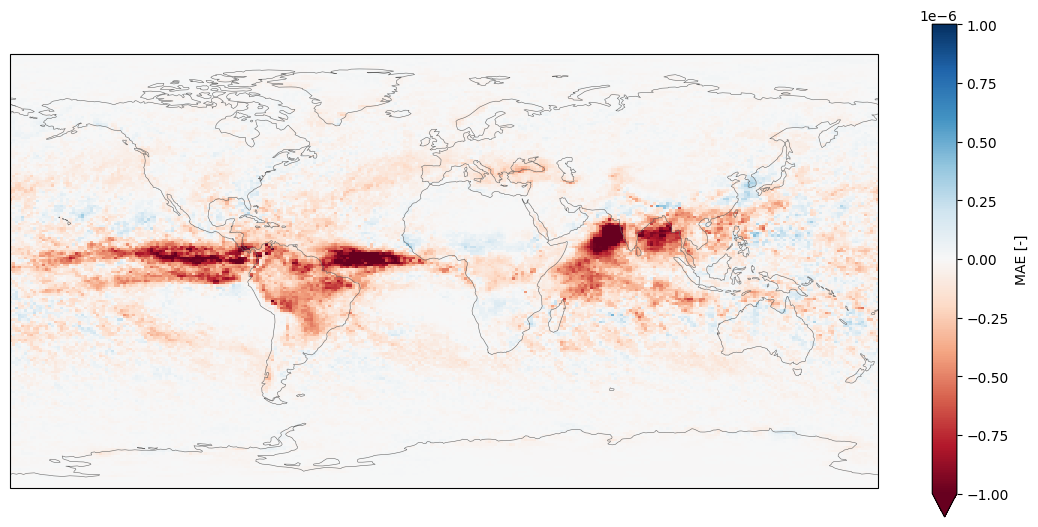

In [45]:
fig, ax = plt.subplots(1,1, figsize=(14,8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
mae_coarse.plot(vmin=-0.000001, vmax=0.000001, cmap='RdBu', transform=ccrs.PlateCarree(), cbar_kwargs={"label": "MAE [-]", "shrink": 0.8})


In [75]:
# Hot spots of both high MAE and high %bias
hot_spot_high = (pbias_coarse>5)&(mae_coarse>1e-7)

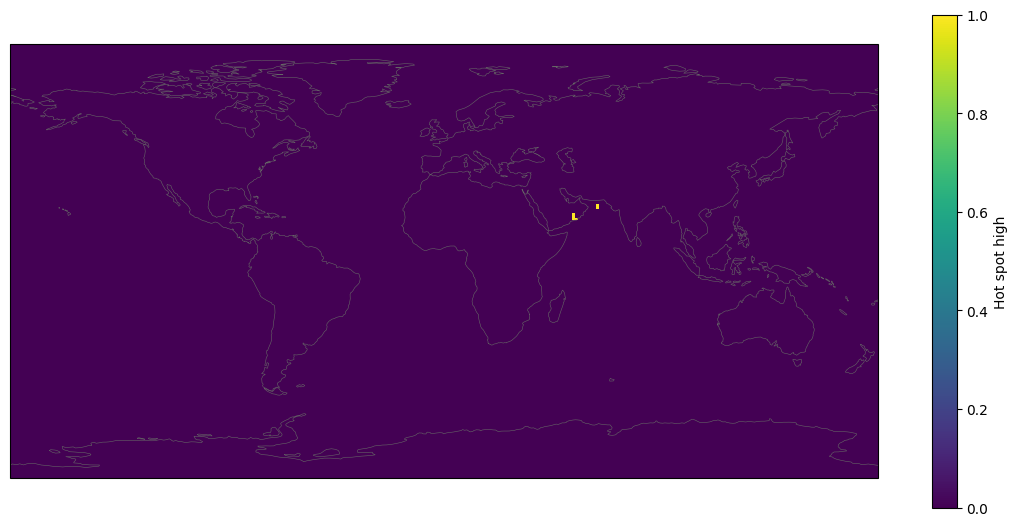

In [76]:
fig, ax = plt.subplots(1,1, figsize=(14,8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
hot_spot_high.plot(transform=ccrs.PlateCarree(), cbar_kwargs={"label": "Hot spot high", "shrink": 0.8})

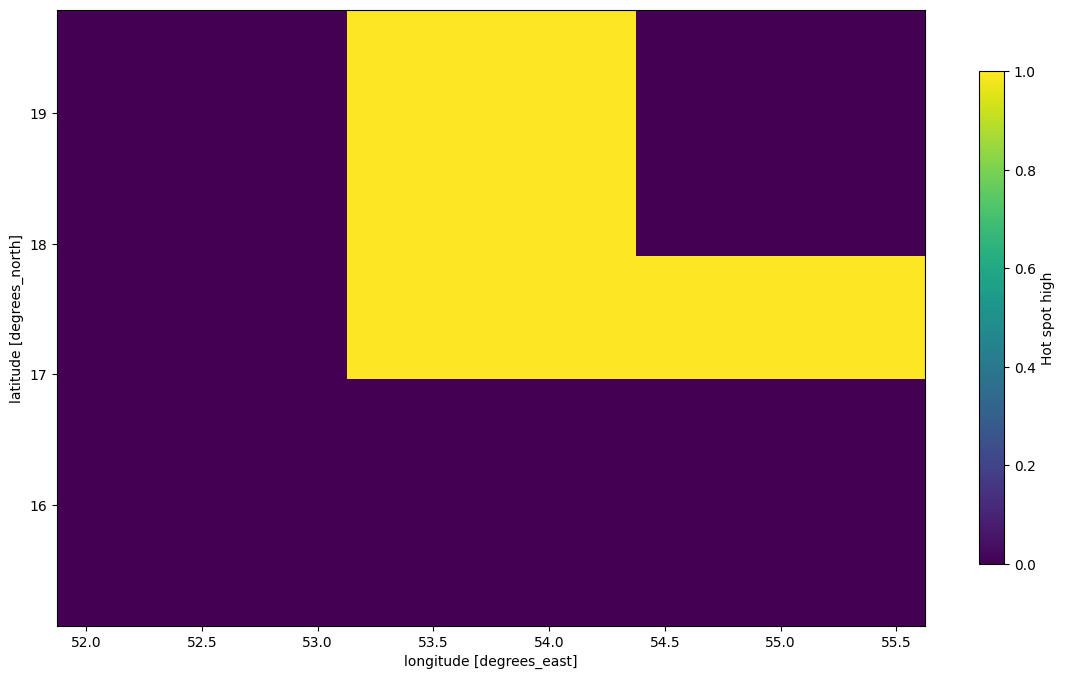

In [87]:
fig, ax = plt.subplots(1,1, figsize=(14,8))
hot_spot_high.sel(lat=slice(15, 20), lon=slice(52,56)).plot(cbar_kwargs={"label": "Hot spot high", "shrink": 0.8})

In [79]:
# Hot spots of both low MAE and low %bias
hot_spot_low = (pbias_coarse<-8)&(mae_coarse<-1e-6)

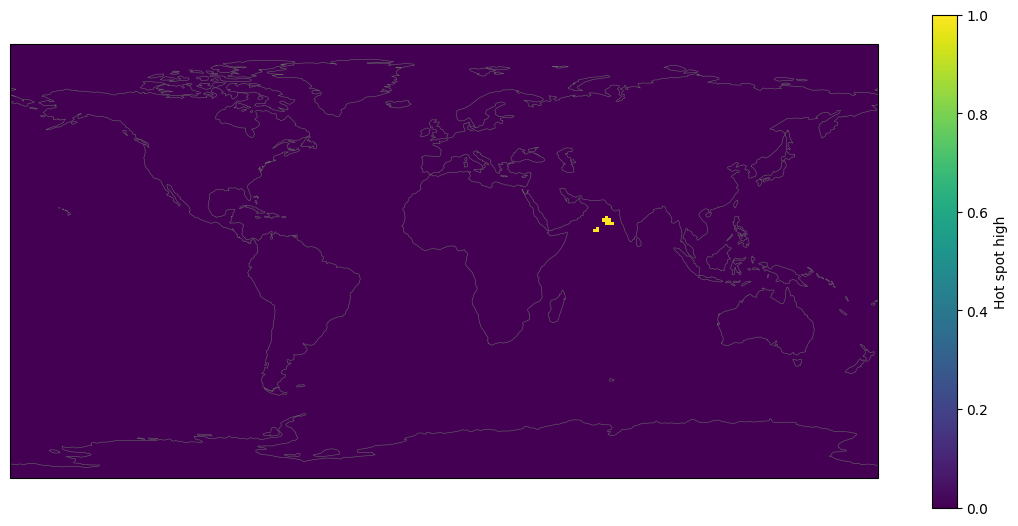

In [80]:
fig, ax = plt.subplots(1,1, figsize=(14,8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
hot_spot_low.plot(transform=ccrs.PlateCarree(), cbar_kwargs={"label": "Hot spot high", "shrink": 0.8})
plt.xticks()

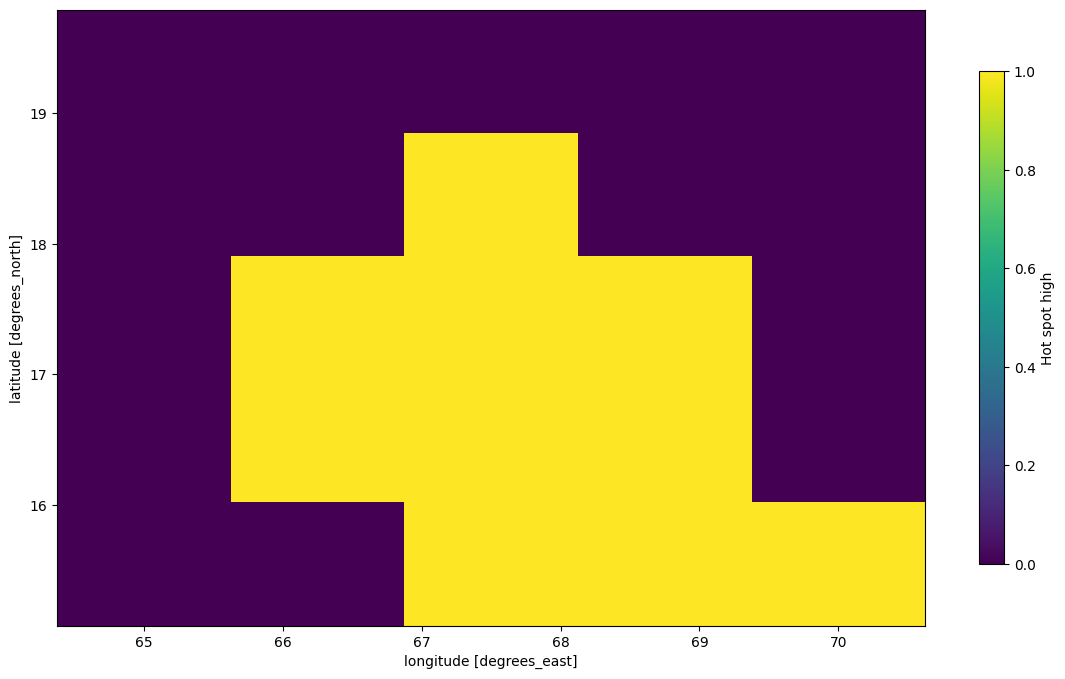

In [91]:
fig, ax = plt.subplots(1,1, figsize=(14,8))
hot_spot_low.sel(lat=slice(15, 20), lon=slice(65,70)).plot(cbar_kwargs={"label": "Hot spot high", "shrink": 0.8})

In [ ]:
# grab pixel ho
hot_spot_coords = {'high': (17, 54),
                   'low': (17, 68)}

# Evaluate bias in fine

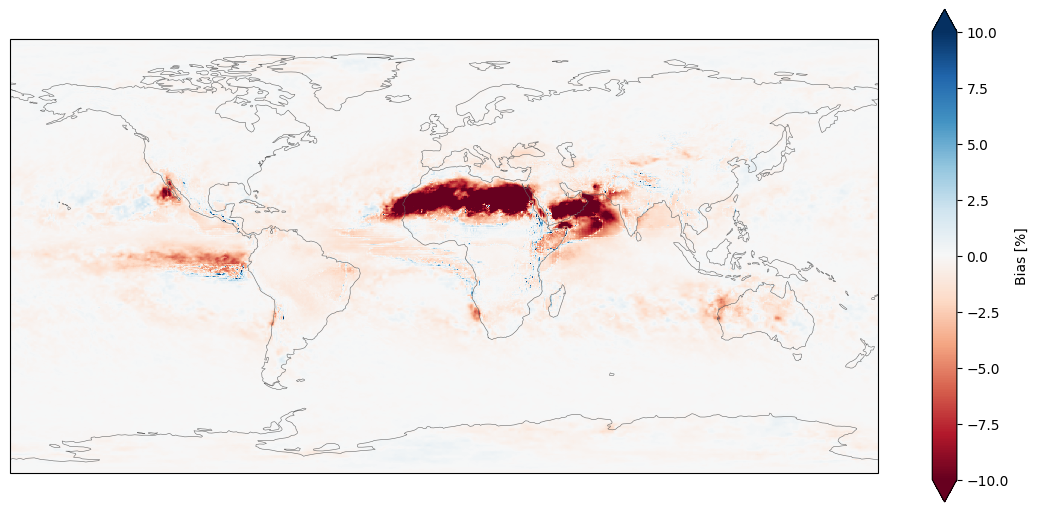

In [42]:
fig, ax = plt.subplots(1,1, figsize=(14,8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
pbias_fine.plot(ax=ax, vmin=-10, vmax=10, cmap='RdBu', transform=ccrs.PlateCarree(), cbar_kwargs={"label": "Bias [%]", "shrink": 0.8})

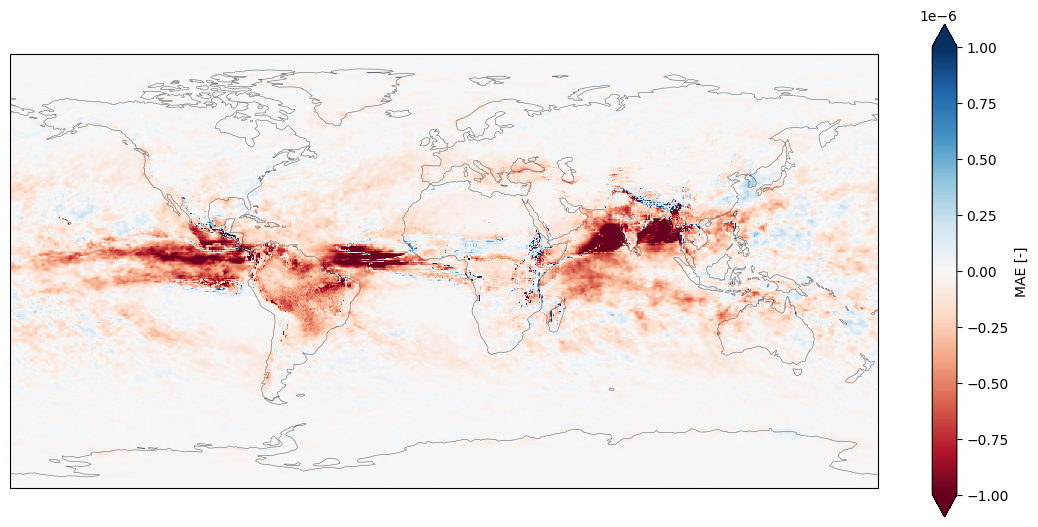

In [43]:
fig, ax = plt.subplots(1,1, figsize=(14,8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
mae_fine.plot(vmin=-0.000001, vmax=0.000001, cmap='RdBu', transform=ccrs.PlateCarree(), cbar_kwargs={"label": "MAE [-]", "shrink": 0.8})


# CDF comparison across locations

Note: `obs_fine` above was subset to the South Africa training region, so we
reload it on the full (global) domain here to compare against all 20
locations in `srm.plotting.locations`. No coarse-grid interpolation is
performed — `coarse_debiased` is plotted on its native grid.

In [93]:
from srm.plotting import locations, plot_cdf_by_location

obs_fine_global = catalog.get("ERA5").to_xarray()[var]
obs_fine_global = obs_fine_global.sel(time=slice('1978', '2014'))

ImportError: cannot import name 'plot_cdf_by_location' from 'srm.plotting' (/scratch/synced/src/srm/plotting.py)

In [44]:
locations = {'Cape Town': (-33.9221, 18.4231)}

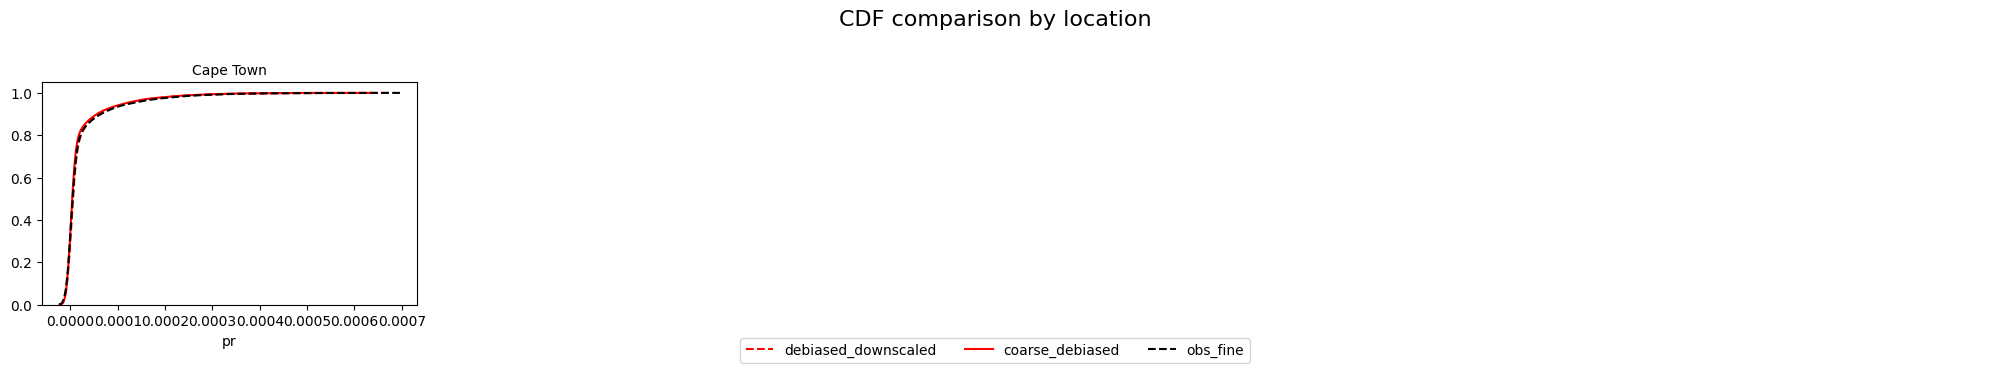

In [46]:
fig = plot_cdf_by_location(
    debiased_downscaled=debiased_downscaled,
    coarse_debiased=coarse_debiased,
    obs_fine=obs_fine_global,
    locations=locations,
    var=var,
)